# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class MyBinaryLogisticRegression:
    def __init__(self, method='gd', penalty='l2', C=1.0, l1_ratio=0.5, 
                 max_iter=1000, learning_rate=0.01, tol=1e-4, 
                 batch_size=32, random_state=None):
        """
        Параметры:
        ----------
        method : {'gd', 'sgd', 'newton'}
            Метод оптимизации
        penalty : {'l2', 'l1', 'elasticnet', 'none'}
            Тип регуляризации
        C : float
            Обратная сила регуляризации (1/λ). Меньше C -> сильнее регуляризация
        l1_ratio : float [0, 1]
            Для elasticnet: доля L1 регуляризации (0 = только L2, 1 = только L1)
        max_iter : int
            Максимальное число итераций
        learning_rate : float
            Скорость обучения для градиентного спуска
        tol : float
            Критерий остановки (изменение функции потерь)
        batch_size : int
            Размер батча для SGD
        random_state : int
            Seed для воспроизводимости
        """
        self.coefs_ = None
        self.intercept_ = None
        self.feature_names_in_ = None
        self.method = method
        self.penalty = penalty
        self.C = C  # C = 1/λ
        self.l1_ratio = l1_ratio
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        self.batch_size = batch_size
        self.random_state = random_state
        self.loss_history_ = []
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _add_intercept(self, X):
        """Добавляет столбец единиц для intercept"""
        return np.hstack((np.ones((X.shape[0], 1)), X))
    
    def _sigmoid(self, z):
        """Сигмоидная функция"""
        # Более устойчивая реализация
        z = np.clip(z, -500, 500)  # Избегаем переполнения
        return 1 / (1 + np.exp(-z))
    
    def get_sigmoid(self, X, W):
        """Вычисление сигмоиды для каждого объекта"""
        z = X @ W
        return self._sigmoid(z)
    
    def _regularization_penalty(self, W):
        """Вычисляет штраф регуляризации"""
        # Пропускаем intercept (первый коэффициент)
        W_without_intercept = W[1:] if len(W) > 1 else W
        
        if len(W_without_intercept) == 0:
            return 0
            
        if self.penalty == 'l2':
            penalty = 0.5 * np.sum(W_without_intercept ** 2)
        elif self.penalty == 'l1':
            penalty = np.sum(np.abs(W_without_intercept))
        elif self.penalty == 'elasticnet':
            l1_penalty = np.sum(np.abs(W_without_intercept))
            l2_penalty = 0.5 * np.sum(W_without_intercept ** 2)
            penalty = self.l1_ratio * l1_penalty + (1 - self.l1_ratio) * l2_penalty
        else:  # 'none'
            penalty = 0
            
        return penalty
    
    def _regularization_gradient(self, W):
        """Вычисляет градиент штрафа регуляризации"""
        n_features = len(W)
        grad = np.zeros(n_features)
        
        # Не регуляризуем intercept
        start_idx = 1 if n_features > 1 else 0
        
        if self.penalty == 'l2' and start_idx < n_features:
            grad[start_idx:] = W[start_idx:]  # Для L2: градиент = w
        elif self.penalty == 'l1' and start_idx < n_features:
            # Субградиент для L1
            grad[start_idx:] = np.sign(W[start_idx:])
            # Обработка случая w=0
            grad[start_idx:][W[start_idx:] == 0] = 0
        elif self.penalty == 'elasticnet' and start_idx < n_features:
            l1_grad = np.sign(W[start_idx:])
            l1_grad[W[start_idx:] == 0] = 0
            l2_grad = W[start_idx:]
            grad[start_idx:] = (self.l1_ratio * l1_grad + 
                               (1 - self.l1_ratio) * l2_grad)
        
        return grad
    
    def get_loss(self, X, Y, W):
        """Вычисление функции потерь с регуляризацией"""
        n_samples = X.shape[0]
        sigmoid = self.get_sigmoid(X, W)
        
        # Основная функция потерь (negative log likelihood)
        epsilon = 1e-15  # Для численной устойчивости
        sigmoid = np.clip(sigmoid, epsilon, 1 - epsilon)
        
        loss = -np.mean(Y * np.log(sigmoid) + (1 - Y) * np.log(1 - sigmoid))
        
        # Добавляем регуляризацию
        reg_penalty = self._regularization_penalty(W)
        loss += reg_penalty / (self.C * n_samples) if self.C > 0 else 0
        
        return loss
    
    def get_grad(self, X, Y, W):
        """Вычисление градиента с регуляризацией"""
        n_samples = X.shape[0]
        sigmoid = self.get_sigmoid(X, W)
        
        # Градиент основной функции
        # grad = X.T @ (sigmoid - Y) / n_samples
        grad = X.T @ (sigmoid - Y)
        
        # Добавляем градиент регуляризации
        if self.C > 0:
            reg_grad = self._regularization_gradient(W)
            # grad += reg_grad / (self.C * n_samples)
            grad += reg_grad / (self.C)
        
        return grad
    
    def get_hess_inv(self, X, W):
        """Вычисление обратной матрицы Гессе с регуляризацией"""
        n_samples = X.shape[0]
        sigmoid = self.get_sigmoid(X, W)
        
        # Диагональная матрица весов
        S = np.diag(sigmoid * (1 - sigmoid))
        
        # Матрица Гессе (без регуляризации)
        # H = X.T @ S @ X / n_samples
        H = X.T @ S @ X
        
        # Добавляем регуляризацию для L2/elasticnet
        if self.penalty in ['l2', 'elasticnet'] and self.C > 0:
            n_features = X.shape[1]
            reg_matrix = np.eye(n_features)
            if n_features > 1:  # Не регуляризуем intercept
                reg_matrix[0, 0] = 0
            # H += reg_matrix / (self.C * n_samples)
            H += reg_matrix / (self.C)
        
        # Для L1 регуляризации матрица Гессе не определена в нуле,
        # используем псевдообратную
        try:
            H_inv = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            # Если матрица вырождена, используем псевдообратную
            H_inv = np.linalg.pinv(H)
        
        return H_inv
    
    def gd(self, X, Y):
        """Градиентный спуск"""
        _, n_features = X.shape
        W = np.random.normal(0, 0.01, size=n_features)
        
        for i in range(self.max_iter):
            loss = self.get_loss(X, Y, W)
            self.loss_history_.append(loss)
            
            # Проверка сходимости
            if i > 0 and abs(self.loss_history_[-2] - loss) < self.tol:
                print(f"GD сошелся за {i+1} итераций")
                break
            
            gradient = self.get_grad(X, Y, W)
            W -= self.learning_rate * gradient
        
        return W
    
    def sgd(self, X, Y):
        """Стохастический градиентный спуск"""
        n_samples, n_features = X.shape
        W = np.random.normal(0, 0.01, size=n_features)
        
        for epoch in range(self.max_iter):
            # Перемешиваем данные
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
            
            epoch_loss = 0
            
            # Проход по батчам
            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)
                X_batch = X_shuffled[i:batch_end]
                Y_batch = Y_shuffled[i:batch_end]
                
                # Вычисляем градиент на батче
                gradient = self.get_grad(X_batch, Y_batch, W)
                
                # Обновляем веса
                W -= self.learning_rate * gradient
                
                # Вычисляем loss на батче
                batch_loss = self.get_loss(X_batch, Y_batch, W)
                epoch_loss += batch_loss * (batch_end - i)
            
            # Средний loss за эпоху
            epoch_loss /= n_samples
            self.loss_history_.append(epoch_loss)
            
            # Проверка сходимости
            if epoch > 0 and abs(self.loss_history_[-2] - epoch_loss) < self.tol:
                print(f"SGD сошелся за {epoch+1} эпох")
                break
        
        return W
    
    def newton(self, X, Y):
        """Метод Ньютона"""
        n_samples, n_features = X.shape
        W = np.random.normal(0, 0.01, size=n_features)
        
        for i in range(self.max_iter):
            loss = self.get_loss(X, Y, W)
            self.loss_history_.append(loss)
            
            # Проверка сходимости
            if i > 0 and abs(self.loss_history_[-2] - loss) < self.tol:
                print(f"Newton сошелся за {i+1} итераций")
                break
            
            gradient = self.get_grad(X, Y, W)
            hess_inv = self.get_hess_inv(X, W)
            
            # Обновление весов методом Ньютона
            W -= hess_inv @ gradient
        
        return W
    
    def fit(self, X, y):
        """
        Обучение модели
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        y : array-like формы (n_samples,)
        
        Returns:
        --------
        self : объект
        """
        # Проверка и преобразование входных данных
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.tolist()
            X = X.values
        else:
            X = np.array(X)
            
        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)
        
        # Добавляем intercept
        X_with_intercept = self._add_intercept(X)
        
        # Выбираем метод оптимизации
        if self.method == 'gd':
            W = self.gd(X_with_intercept, y)
        elif self.method == 'sgd':
            W = self.sgd(X_with_intercept, y)
        elif self.method == 'newton':
            W = self.newton(X_with_intercept, y)
        else:
            raise ValueError(f"Неизвестный метод: {self.method}")
        
        # Сохраняем коэффициенты
        self.intercept_ = W[0]
        self.coefs_ = W[1:] if len(W) > 1 else np.array([])
        
        return self
    
    def predict_proba(self, X):
        """
        Предсказание вероятностей
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        
        Returns:
        --------
        proba : array формы (n_samples, 2)
            Вероятности классов [P(y=0), P(y=1)]
        """
        if isinstance(X, pd.DataFrame):
            X = X.values
        else:
            X = np.array(X)
        
        if self.coefs_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")
        
        # Добавляем intercept
        X_with_intercept = self._add_intercept(X)
        W = np.concatenate([[self.intercept_], self.coefs_])
        
        # Вычисляем вероятности для класса 1
        proba_positive = self.get_sigmoid(X_with_intercept, W)
        proba_negative = 1 - proba_positive
        
        return np.column_stack([proba_negative, proba_positive])
    
    def predict(self, X, threshold=0.5):
        """
        Предсказание классов
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        threshold : float
            Порог для бинаризации вероятностей
        
        Returns:
        --------
        y_pred : array формы (n_samples,)
            Предсказанные классы (0 или 1)
        """
        proba = self.predict_proba(X)
        return (proba[:, 1] >= threshold).astype(int)
    
    def score(self, X, y, sample_weight=None):
        """
        Вычисление accuracy
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        y : array-like формы (n_samples,)
        sample_weight : array-like формы (n_samples,), optional
            Веса объектов
        
        Returns:
        --------
        score : float
            Accuracy модели
        """
        y_pred = self.predict(X)
        
        if sample_weight is not None:
            # Взвешенная accuracy
            correct = (y_pred == y).astype(float)
            return np.average(correct, weights=sample_weight)
        else:
            return np.mean(y_pred == y)
    
    def log_loss(self, X, y):
        """
        Вычисление логарифмической потери
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        y : array-like формы (n_samples,)
        
        Returns:
        --------
        loss : float
            Log loss
        """
        proba = self.predict_proba(X)
        epsilon = 1e-15
        proba = np.clip(proba, epsilon, 1 - epsilon)
        
        # Log loss для бинарной классификации
        loss = -np.mean(y * np.log(proba[:, 1]) + 
                       (1 - y) * np.log(proba[:, 0]))
        return loss
    
    def plot_loss_history(self):
        """Визуализация истории потерь"""
        if not self.loss_history_:
            print("Модель еще не обучена")
            return
        
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history_, label='Loss')
        plt.xlabel('Iteration/Epoch')
        plt.ylabel('Loss')
        plt.title(f'Loss History ({self.method} method, {self.penalty} penalty)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

In [3]:
df = pd.read_csv('./data/data.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


In [4]:
df['species'].unique(), df['island'].unique()

(array(['Adelie', 'Gentoo'], dtype=object),
 array(['Torgersen', 'Biscoe', 'Dream'], dtype=object))

In [5]:
# Target Encoder
df_te = df.copy()
df_te['species'] = df_te['species'].apply(lambda x: 1 if x == 'Adelie' else 0)

island_means = df_te.groupby('island')['species'].mean().to_dict()
df_te['island'] = df_te['island'].map(island_means)

In [6]:
df_te.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,1,1.0,39.1,18.7,181.0,3750.0,2007
1,1,1.0,39.5,17.4,186.0,3800.0,2007
2,1,1.0,40.3,18.0,195.0,3250.0,2007
3,1,1.0,36.7,19.3,193.0,3450.0,2007
4,1,1.0,39.3,20.6,190.0,3650.0,2007


In [7]:
X = df_te.drop(columns = ['species'])
y = df_te['species']

In [117]:
# df = pd.read_csv('https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv', sep=';')

# df_sample = df[np.logical_and(df['age'] >= 18, df['age'] <= 50)]
# X = df_sample[['height', 'weight']]
# y = df_sample['male']

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [29]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='lbfgs', random_state=42, penalty='l2').fit(X, y)
clf.intercept_, clf.coef_

(array([1.63512018]),
 array([[ 2.21851527, -2.1041522 ,  3.50880376, -3.30023237, -2.53344888,
          0.31767211]]))

In [28]:
clf = MyBinaryLogisticRegression(method='newton', random_state=42, penalty='l2').fit(X, y)
clf.intercept_, clf.coefs_

Newton сошелся за 6 итераций


(np.float64(1.6334055097180686),
 array([ 2.2199365 , -2.10394422,  3.50675015, -3.30194651, -2.52889838,
         0.31800951]))

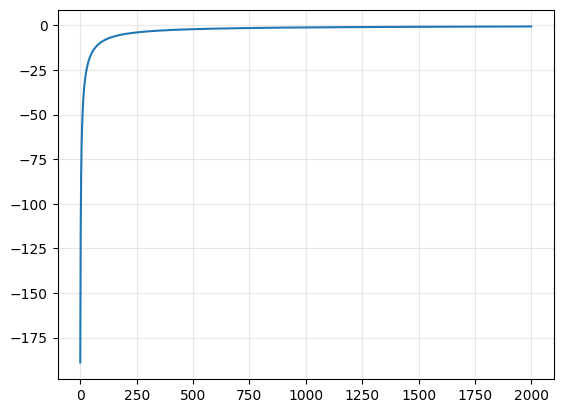

[ 3.28647122  4.54807278 -5.38339807 11.4866507  -8.50791791 -6.58715697
  1.59897801]


In [122]:
clf = MyBinaryLogisticRegression(method='gd')
print(clf.fit(X, y).coefs_)

# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию.

**Решение:**

1. Найдем функцию потерь

Правдоподопие по условию:
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}, \quad \mathbb P(C_j|x_i) = \frac{e ^ {w_j^Tx_i}}{\sum_{l = 1}^M e ^ {w_l^Tx_i}}
$$

Введем обозначения:
$$
t_{ij} = y_{ij}, \quad p_{ij} = \mathbb P(C_j|x_i)
$$

Логарифмируем функцию правдоподобия:
$$
\mathbb L(\omega) = \sum_{i = 1}^N\sum_{j = 1}^M t_{ij} \ln{p_{ij}}
$$

Loss-функция:
$$
J(\omega) = -\frac{1}{N}L(\omega) = -\frac{1}{N}\sum_{i = 1}^N\sum_{j = 1}^M t_{ij} \ln{p_{ij}}
$$

В матричной форме:

Пусть
- $X \in \mathbb R^{N \times d}$ - матрица объекты-признаки
- $W \in \mathbb R^{d \times M}$ - матрица весов
- $T \in \mathbb R^{N \times M}$ - one-hot матрица целевых классов

Тогда:
$$
S = XW \in \mathbb R^{N \times M}, \\
P = \text{softmax} (S), \\
P_{ij} = \frac{e^{S_{ij}}} {\sum_{l = 1}^M e ^{S_{il}}}
$$

Loss-функция:
$$
J(W) =  -\frac{1}{N} \sum_{i = 1}^N\sum_{j = 1}^M t_{ij} \ln{p_{ij}} =  -\frac{1}{N} \text{trace}(T^T \ln{P})
$$
где $\ln{P}$ - поэлементный логарифм

2. Градиент

ToDo

Accuracy: 0.9500


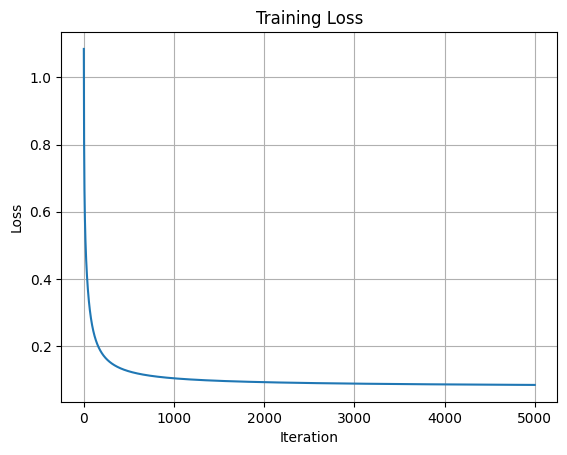

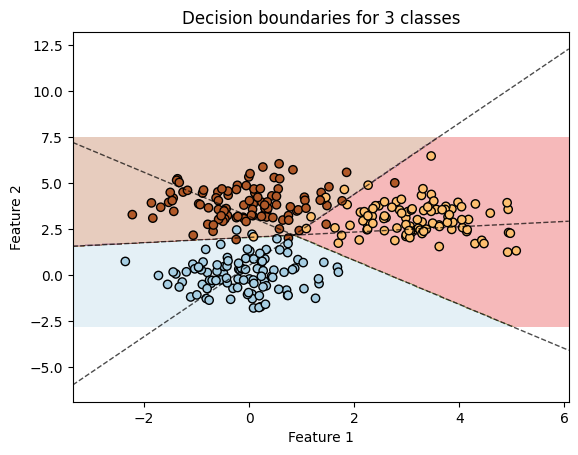

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

class SoftmaxRegression:
    def __init__(self, learning_rate=0.1, max_iter=1000, tol=1e-4, reg=0.0):
        self.lr = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.reg = reg
        self.W = None
        self.loss_history = []
    
    def softmax(self, S):
        expS = np.exp(S - np.max(S, axis=1, keepdims=True))
        return expS / np.sum(expS, axis=1, keepdims=True)
    
    def fit(self, X, y):
        N, d = X.shape
        M = len(np.unique(y))
        self.classes_ = np.unique(y)
        
        # One-hot encode y
        T = np.eye(M)[y]
        
        # Initialize weights
        self.W = np.random.randn(d, M) * 0.01
        
        for it in range(self.max_iter):
            # Forward pass
            S = X @ self.W
            P = self.softmax(S)
            
            # Loss (cross-entropy)
            loss = -np.sum(T * np.log(P + 1e-15)) / N + self.reg * np.sum(self.W**2) / 2
            self.loss_history.append(loss)
            
            # Gradient
            grad = -X.T @ (T - P) / N + self.reg * self.W
            
            # Update weights
            self.W -= self.lr * grad
            
            if it > 0 and np.linalg.norm(grad) < self.tol:
                print(f'Converged at iteration {it}')
                break
    
    def predict_proba(self, X):
        S = X @ self.W
        P = self.softmax(S)
        return P
    
    def predict(self, X):
        P = self.predict_proba(X)
        return np.argmax(P, axis=1)

# Generate synthetic data
N = 300
centers = [[0, 0], [3, 3], [0, 4]]
X, y = make_blobs(n_samples=N, centers=centers, n_features=2, cluster_std=0.9, random_state=42)

# Add bias term (first column 1)
X_b = np.c_[np.ones(X.shape[0]), X]

# Split
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# Train
model = SoftmaxRegression(learning_rate=0.1, max_iter=5000, reg=0.0)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f'Accuracy: {accuracy:.4f}')

# Plot loss
plt.figure()
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

# Plot decision boundaries
plt.figure()
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
Z = model.predict_proba(grid)
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision boundaries for 3 classes')

# Plot hyperplanes (decision lines between pairs of classes)
for i in range(model.W.shape[1]):
    for j in range(i+1, model.W.shape[1]):
        w_diff = model.W[:, i] - model.W[:, j]
        # Decision line: w_diff^T x = 0
        # For 2D features (plus bias): w0 + w1*x1 + w2*x2 = 0
        if abs(w_diff[2]) > 1e-5:
            x1_vals = np.array([x_min, x_max])
            x2_vals = -(w_diff[0] + w_diff[1]*x1_vals) / w_diff[2]
            plt.plot(x1_vals, x2_vals, 'k--', linewidth=1, alpha=0.7)
        else:
            # Vertical line if w2 ≈ 0
            if abs(w_diff[1]) > 1e-5:
                x1_val = -w_diff[0] / w_diff[1]
                plt.axvline(x=x1_val, color='k', linestyle='--', alpha=0.7)

plt.show()